<a href="https://colab.research.google.com/github/RafaihAbbasi/Auto-Tagging-Support-Tickets-Using-LLM/blob/main/Auto_Tagging_Support_Tickets_Using_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install the Google GenAI SDK and necessary data analysis tools
!pip install google-genai pandas scikit-learn matplotlib seaborn -q

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google import genai
from google.colab import userdata
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Gemini Client using the secure Colab secret
try:
    api_key = userdata.get('GEMINI_API_KEY')
    client = genai.Client(api_key=api_key)
    print("🚀 Gemini Client successfully initialized!")
except Exception as e:
    print(f"❌ Initialization error: Check your Colab Secrets for GEMINI_API_KEY. Details: {e}")

🚀 Gemini Client successfully initialized!


In [2]:
# Define system valid categories
ALLOWED_TAGS = ["Billing/Invoices", "Technical Support", "Account Access", "Feature Request", "Bug Report"]

# Create a synthetic dataset of real-world support ticket scenarios
data = {
    "ticket_text": [
        "My premium subscription was renewed yesterday, but I got charged twice on my credit card. Please issue a refund.",
        "Every time I try to click the export button, the mobile app crashes instantly with a blank screen.",
        "I forgot my password and the security reset email link isn't landing in my inbox. Can you assist?",
        "It would be amazing if you guys could add a dark mode toggler to the desktop version dashboard interface.",
        "The login form says 'Invalid Credentials' even though I just reset my password successfully five minutes ago.",
        "Our team needs an integration option with Slack so we can track project progress directly in channels.",
        "The PDF reports generated by the tool have overlapping text on the third page, making it unreadable.",
        "I need to update my corporate billing address on my account profile before the upcoming renewal date.",
        "Your server response times have been incredibly slow today. API calls are timing out continuously.",
        "Can we get a bulk upload feature for csv contacts? Doing it one by one is taking way too long."
    ],
    "ground_truth_tag": [
        "Billing/Invoices", "Bug Report", "Account Access", "Feature Request", "Account Access",
        "Feature Request", "Bug Report", "Billing/Invoices", "Technical Support", "Feature Request"
    ]
}

df = pd.DataFrame(data)
print(f"Dataset ready! Total tickets to evaluate: {len(df)}")
df.head()

Dataset ready! Total tickets to evaluate: 10


,ticket_text,ground_truth_tag
0,"My premium subscription was renewed yesterday,...",Billing/Invoices
1,"Every time I try to click the export button, t...",Bug Report
2,I forgot my password and the security reset em...,Account Access
3,It would be amazing if you guys could add a da...,Feature Request
4,The login form says 'Invalid Credentials' even...,Account Access


In [4]:
# 1. Zero-Shot Prompt Template
def get_zero_shot_prompt(ticket_text):
    return f"""
    You are an AI support ticket routing specialist. Analyze the ticket content and classify it into exactly the top 3 most relevant tags from the allowed list, ordered by highest confidence first.

    Allowed Tags: {ALLOWED_TAGS}

    Ticket: "{ticket_text}"

    Return your output strictly as a valid JSON object matching this structure:
    {{"tags": ["Tag1", "Tag2", "Tag3"]}}
    Do not add extra explanations, markdown blocks, or text.
    """

# 2. Few-Shot Prompt Template
def get_few_shot_prompt(ticket_text):
    return f"""
    You are an AI support ticket routing specialist. Analyze the ticket content and classify it into exactly the top 3 most relevant tags from the allowed list, ordered by highest confidence first.

    Allowed Tags: {ALLOWED_TAGS}

    ###
    Example 1:
    Ticket: "Can I switch my payment plan from monthly to an annual corporate invoice subscription?"
    Output: {{"tags": ["Billing/Invoices", "Account Access", "Technical Support"]}}
    ###
    Example 2:
    Ticket: "The attachment clip button isn't responsive when using the web app via Safari."
    Output: {{"tags": ["Bug Report", "Technical Support", "Feature Request"]}}
    ###

    Ticket: "{ticket_text}"

    Return your output strictly as a valid JSON object matching this structure:
    {{"tags": ["Tag1", "Tag2", "Tag3"]}}
    Do not add extra explanations, markdown blocks, or text.
    """

In [5]:
def classify_ticket(text, strategy="zero_shot"):
    prompt = get_zero_shot_prompt(text) if strategy == "zero_shot" else get_few_shot_prompt(text)

    try:
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=prompt,
        )

        # Parse the raw text string into clean JSON data safely
        clean_json_str = response.text.replace("```json", "").replace("```", "").strip()
        parsed_output = json.loads(clean_json_str)
        tags = parsed_output.get("tags", [])

        # Guarantee that exactly 3 outputs are always present to avoid structural crashes
        while len(tags) < 3:
            tags.append("N/A")
        return tags[:3]
    except Exception as e:
        return ["Error", "Error", "Error"]

print("⚡ Running Zero-Shot Classification...")
df['zero_shot_top3'] = df['ticket_text'].apply(lambda x: classify_ticket(x, "zero_shot"))

print("⚡ Running Few-Shot Classification...")
df['few_shot_top3'] = df['ticket_text'].apply(lambda x: classify_ticket(x, "few_shot"))

# Extract primary (Top-1) tag for metric alignment
df['zero_shot_primary'] = df['zero_shot_top3'].apply(lambda x: x[0])
df['few_shot_primary'] = df['few_shot_top3'].apply(lambda x: x[0])

print("\n🎉 Model processing complete!")
df[['ticket_text', 'ground_truth_tag', 'zero_shot_primary', 'few_shot_primary']].head()

⚡ Running Zero-Shot Classification...
⚡ Running Few-Shot Classification...

🎉 Model processing complete!


,ticket_text,ground_truth_tag,zero_shot_primary,few_shot_primary
0,"My premium subscription was renewed yesterday,...",Billing/Invoices,Billing/Invoices,Billing/Invoices
1,"Every time I try to click the export button, t...",Bug Report,Bug Report,Bug Report
2,I forgot my password and the security reset em...,Account Access,Account Access,Account Access
3,It would be amazing if you guys could add a da...,Feature Request,Feature Request,Feature Request
4,The login form says 'Invalid Credentials' even...,Account Access,Error,Account Access


In [6]:
# Calculate basic accuracies for comparison
zero_acc = accuracy_score(df['ground_truth_tag'], df['zero_shot_primary'])
few_acc = accuracy_score(df['ground_truth_tag'], df['few_shot_primary'])

print("=========================================")
print(f"📊 EVALUATION REPORT: ZERO-SHOT VS FEW-SHOT")
print("=========================================")
print(f"Zero-Shot Primary Target Accuracy: {zero_acc * 100:.1f}%")
print(f"Few-Shot Primary Target Accuracy: {few_acc * 100:.1f}%\n")

print("--- Zero-Shot Classification Report ---")
print(classification_report(df['ground_truth_tag'], df['zero_shot_primary'], zero_division=0))

print("--- Few-Shot Classification Report ---")
print(classification_report(df['ground_truth_tag'], df['few_shot_primary'], zero_division=0))

📊 EVALUATION REPORT: ZERO-SHOT VS FEW-SHOT
Zero-Shot Primary Target Accuracy: 70.0%
Few-Shot Primary Target Accuracy: 70.0%

--- Zero-Shot Classification Report ---
                   precision    recall  f1-score   support

   Account Access       1.00      0.50      0.67         2
 Billing/Invoices       1.00      1.00      1.00         2
       Bug Report       0.67      1.00      0.80         2
            Error       0.00      0.00      0.00         0
  Feature Request       1.00      0.67      0.80         3
Technical Support       0.00      0.00      0.00         1

         accuracy                           0.70        10
        macro avg       0.61      0.53      0.54        10
     weighted avg       0.83      0.70      0.73        10

--- Few-Shot Classification Report ---
                   precision    recall  f1-score   support

   Account Access       1.00      1.00      1.00         2
 Billing/Invoices       1.00      0.50      0.67         2
       Bug Report       0

/tmp/ipykernel_7818/1581559531.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=strategies, y=accuracies, palette="Blues_d")


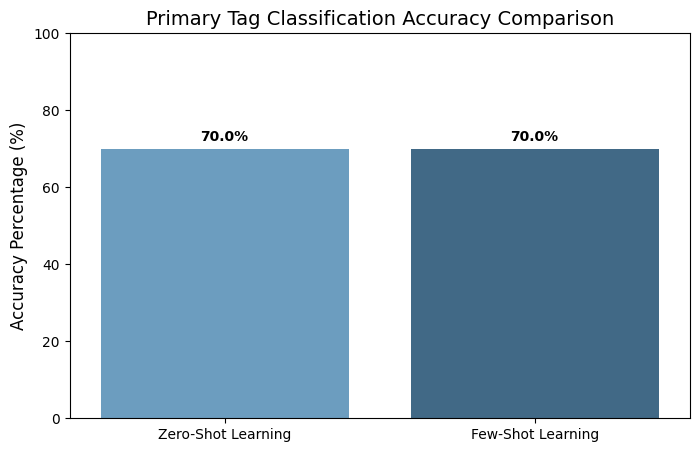

In [7]:
# Visualizing performance comparison
strategies = ['Zero-Shot Learning', 'Few-Shot Learning']
accuracies = [zero_acc * 100, few_acc * 100]

plt.figure(figsize=(8, 5))
sns.barplot(x=strategies, y=accuracies, palette="Blues_d")
plt.title('Primary Tag Classification Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy Percentage (%)', fontsize=12)
plt.ylim(0, 100)

for i, v in enumerate(accuracies):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.show()